<a href="https://colab.research.google.com/github/marianoInsa/dimiasa-models/blob/main/notebooks/03-E02-Resampleo-Unificado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 2: Validación de Resampleo a 100 Hz

**Objetivo:** Evaluar la calidad del resampleo de cada dataset a 100 Hz usando métricas que reflejan fidelidad morfológica real.

**Características:**
- Resampleo sobre el trials completos
- Método único estandarizado (`resample_poly`) para todos los datasets
- Detección del desfase temporal (phase shift) entre picos
- Resumen comparativo cross-dataset al final

**Datasets soportados:** SisFall (200 Hz) · FallAllD (238 Hz)  
**Frecuencia objetivo:** 100 Hz

### **Métricas**

| Métrica | Descripción |
| :--- | :--- |
| **SNR in-band (dB)** | Fidelidad de la señal en la banda de interés (0–25 Hz). |
| **Pearson r** | Similitud directa de forma de la curva en los mismos instantes de tiempo. |
| **DTW normalizado** | Similitud dinámica de forma; tolera pequeños desfases. |
| **Phase shift (ms)** | Desplazamiento temporal del pico de impacto. Diagnostica si se mueve el evento de lugar. |
| **Atenuación pico filtrado (%)** | Pérdida del pico relativa a la señal filtrada. Mide la degradación real en la banda válida. |

#### *SNR in-band (dB)*

> Se buscan valores altos. Mide la claridad de la señal frente al ruido.

| Umbrales | Media | P50 (Mediana) | P95 | Máximo |
| --- | --- | --- | --- | --- |
| **Bueno** | ≈ P50 | **> 20 dB** | > 25 dB | Alto |
| **Aceptable** | ≥ P50 | **> 15 dB** | > 20 dB | Irrelevante |
| ***Alerta*** | >> P50 (promedio inflado) | **< 12 dB** (destrucción) | Bajo | - |

#### *Pearson r*

> Se buscan valores cercanos a 1.0. Mide correlación directa de forma.

| Umbrales | Media | P50 (Mediana) | P95 | Máximo |
| --- | --- | --- | --- | --- |
| **Bueno** | > 0.90 | **> 0.93** | > 0.98 | ≈ 1.0 |
| **Aceptable** | > 0.80 | **0.80 – 0.93** | > 0.90 | ≈ 1.0 |
| ***Alerta*** | < 0.80 | **< 0.80** (deformación) | < 0.85 | Irrelevante |

#### *DTW normalizado*

> Se buscan valores bajos. Mide deformación tolerando desfase.

| Umbrales | Media | P50 (Mediana) | P95 | Máximo |
| --- | --- | --- | --- | --- |
| **Bueno** | < 0.03 | **< 0.03** | < 0.05 | Bajo |
| **Aceptable** | < 0.05 | **0.03 – 0.05** | < 0.08 | < 0.10 |
| ***Alerta*** | > 0.05 | **> 0.05** | > 0.10 | Muy alto |

#### *Phase shift (ms)*

> Se buscan valores cercanos a 0. Mide corrimiento en el tiempo.

| Umbrales | Media | P50 (Mediana) | P95 | Máximo |
| --- | --- | --- | --- | --- |
| **Bueno** | ≈ 0 | **≈ 0** | **< 40 ms** | < 50 ms |
| **Aceptable** | < 40 ms | < 10 ms | **< 100 ms** | Irrelevante |
| ***Alerta*** | > 50 ms | > 40 ms | **> 100 ms** (sistémico) | Irrelevante |

#### *Atenuación pico filtrado (%)*

> Se buscan porcentajes bajos. Mide qué tanto achatamos el impacto.

| Umbrales | Media | P50 (Mediana) | P95 | Máximo |
| --- | --- | --- | --- | --- |
| **Bueno** | < 10% | **< 10%** | **< 20%** | Irrelevante |
| **Aceptable** | 10% – 15% | **10% – 15%** | **20% – 30%** | Irrelevante |
| ***Alerta*** | > 15% | **> 15%** (filtro agresivo) | **> 30%** | Irrelevante |

## 0 · Instalación y librerías

In [28]:
%pip install numpy pandas scipy dtaidistance azure-storage-file-datalake --quiet

In [29]:
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import resample_poly, welch, butter, filtfilt
from scipy.stats import pearsonr
from dtaidistance import dtw as dtw_lib
from google.colab import userdata
from azure.storage.filedatalake import DataLakeServiceClient

#warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,          # Configuración global para los gráficos
                     "grid.linestyle": "--", "grid.alpha": 0.45})

FS_TARGET = 100         # Hz objetivo
EVAL_WINDOW_SEC = 2.0   # ventana de segundos alrededor del pico
KAISER_BETA = 5.0       # parámetro del filtro FIR (resample_poly)

print(f"Configuración: FS_TARGET={FS_TARGET} Hz | ventana de eval={EVAL_WINDOW_SEC}s | Kaiser β={KAISER_BETA}")

Configuración: FS_TARGET=100 Hz | ventana de eval=2.0s | Kaiser β=5.0


## 1 · Carga de datasets desde Azure Data Lake

Una sola celda que descarga los cuatro CSV.  
Si alguno no está disponible se omite sin romper el notebook.

In [30]:
# --- Conexión
CONNECTION_STRING = userdata.get("cadenaAzure")
service_client = DataLakeServiceClient.from_connection_string(CONNECTION_STRING)
fs_bronce = service_client.get_file_system_client("bronce")
dir_falls = fs_bronce.get_directory_client("falls")

def _load_csv(filename: str) -> pd.DataFrame | None:
    try:
        content = dir_falls.get_file_client(filename).download_file().readall()
        df = pd.read_csv(io.BytesIO(content))
        print(f"  ✓  {filename:35s}  →  {len(df):>8,} filas")
        return df
    except Exception as e:
        print(f"  ✗  {filename:35s}  →  ERROR: {e}")
        return None

print("Descargando datasets…")
datasets = {
    "FallAllD": {"df": _load_csv("FallAllD-Reduced.csv"), "fs": 238},
    "SisFall":  {"df": _load_csv("SisFall-Reduced.csv"),  "fs": 200},
}

# Diccionario global para los resultados
RESULTS: dict[str, dict] = {}

print("\nCarga completa.")

Descargando datasets…
  ✓  FallAllD-Reduced.csv                 →  8,558,480 filas
  ✓  SisFall-Reduced.csv                  →  15,858,929 filas

Carga completa.


## 2 · Funciones de análisis compartidas

Estas funciones son reutilizadas por cada sección de dataset.  
**No modificar entre secciones** — son el núcleo del experimento mejorado.

In [31]:
# --- Resampleo ----------------------------------------------------------------
def get_poly_factors(fs_orig: int, fs_target: int) -> tuple[int, int]:
    """Devuelve (up, down) reducidos al mínimo común divisor."""
    from math import gcd
    g = gcd(fs_target, fs_orig)
    return fs_target // g, fs_orig // g


def resample_trial(signal: np.ndarray, fs_orig: int, fs_target: int) -> np.ndarray:
    """
    Resamplea un trial COMPLETO con resample_poly y filtro Kaiser consistente.
    Operar sobre el trial completo evita artefactos de borde (efecto Gibbs)
    que aparecen cuando se resamplea una ventana corta alrededor del pico.
    """
    up, down = get_poly_factors(fs_orig, fs_target)
    return resample_poly(signal, up=up, down=down, window=("kaiser", KAISER_BETA))


# --- Filtro pasa-bajos de Butterworth
def lowpass(signal: np.ndarray, fs: int, cutoff: float = None) -> np.ndarray:
    """
    Filtra la señal original al mismo ancho de banda que la señal resampleada
    (Nyquist del target = FS_TARGET/2), permitirá el paso de las frecuencias
    menores al corte y bloqueará las mayores. Permite comparar señales en la misma
    banda antes de calcular correlación/SNR, eliminando la ventaja artificial
    de la señal original al tener contenido de alta frecuencia.
    """
    if cutoff is None:
        cutoff = FS_TARGET / 2.0 - 0.5   # ligeramente por debajo de Nyquist
    nyq = fs / 2.0

    # Si la señal ya está limitada por debajo de la frecuencia de corte,
    # no tiene sentido filtrar: devolver la señal tal cual
    if cutoff >= nyq * 0.99:
        return signal.copy()
    b, a = butter(8, cutoff / nyq, btype="low")
    return filtfilt(b, a, signal)


# --- Métricas -----------------------------------------------------------------
def snr_inband(orig: np.ndarray, resampled: np.ndarray,
               fs_orig: int, fs_target: int) -> float:
    """
    SNR en la banda válida [0, FS_TARGET/2] Hz.
    Señal = la parte de la original que SÍ puede representar el resampleo.
    Ruido  = diferencia entre esa señal de referencia y la resampleada
             interpolada al mismo eje temporal.
    """
    # Interpolar resampleada al eje temporal de la original para poder restar
    n_orig = len(orig)
    n_res  = len(resampled)
    t_orig = np.linspace(0, 1, n_orig)
    t_res  = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)

    orig_filtered = lowpass(orig, fs_orig)
    noise = orig_filtered - resampled_interp
    power_signal = np.mean(orig_filtered ** 2)
    power_noise  = np.mean(noise ** 2)
    if power_noise == 0:
        return np.inf
    return 10 * np.log10(power_signal / power_noise)


def pearson_inband(orig: np.ndarray, resampled: np.ndarray,
                   fs_orig: int) -> float:
    """
    Correlación de Pearson entre la original filtrada a la banda del target
    y la resampleada (interpolada al eje temporal de la original).
    Mide similitud morfológica.
    """
    n_orig = len(orig)
    n_res  = len(resampled)
    t_orig = np.linspace(0, 1, n_orig)
    t_res  = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)
    orig_filtered    = lowpass(orig, fs_orig)
    r, _ = pearsonr(orig_filtered, resampled_interp)
    return r


def dtw_normalized(orig: np.ndarray, resampled: np.ndarray,
                   fs_orig: int, fs_target: int) -> float:
    """
    Distancia DTW normalizada por la longitud de la secuencia más larga.
    Ambas señales se normalizan (zscore) antes de comparar para que la escala
    no domine y lo que se mida sea la similitud de forma (shape).
    Se submuestrea a FS_TARGET para comparar señales del mismo tamaño.
    """
    up, down = get_poly_factors(fs_orig, fs_target)
    orig_resampled_to_target = resample_poly(orig, up=up, down=down,
                                              window=("kaiser", KAISER_BETA))

    def zscore(x):
        s = x.std()
        return (x - x.mean()) / s if s > 0 else x - x.mean()

    a = zscore(orig_resampled_to_target).astype(np.double)
    b = zscore(resampled).astype(np.double)
    # Limitar longitud para performance (máx 500 muestras = 10s a 50 Hz)
    max_len = 500
    if len(a) > max_len:
        a = a[:max_len]
        b = b[:max_len]
    dist = dtw_lib.distance_fast(a, b)
    return dist / max(len(a), len(b))


def peak_phase_shift_ms(orig: np.ndarray, resampled: np.ndarray,
                         fs_orig: int, fs_target: int) -> float:
    """
    Desfase temporal entre el pico de la original y el pico de la resampleada,
    expresado en milisegundos.  Un desfase alto indica que el resampleo
    desplaza la localización del evento de impacto en el tiempo.
    """
    t_peak_orig = orig.argmax() / fs_orig
    t_peak_res  = resampled.argmax() / fs_target
    return abs(t_peak_orig - t_peak_res) * 1000   # ms


def peak_attenuation_pct(orig: np.ndarray, resampled: np.ndarray,
                          fs_orig: int) -> float:
    """
    Atenuación del pico relativa a la señal original FILTRADA (no a la cruda).
    Al comparar contra la señal filtrada se elimina la energía que el filtro
    antialiasing correctamente debe eliminar, midiendo solo la degradación
    real sobre la banda que sí debería conservarse.
    """
    orig_filtered = lowpass(orig, fs_orig)
    max_orig = np.max(orig_filtered)
    n_res    = len(resampled)
    n_orig   = len(orig)
    t_orig   = np.linspace(0, 1, n_orig)
    t_res    = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)
    max_res  = np.max(resampled_interp)
    return abs(max_orig - max_res) / max_orig * 100 if max_orig > 0 else 0.0


# --- Pipeline de análisis por trial -------------------------------------------
def analyze_trial(trial_df: pd.DataFrame, fs_orig: int,
                  fs_target: int = FS_TARGET) -> dict | None:
    """
    Analiza un trial completo:
      1. Calcula las resultantes de acelerómetro y giroscopio
      2. Resamplea el trial COMPLETO
      3. Extrae ventana focal alrededor del pico (en la señal resampleada)
      4. Calcula las 5 métricas para cada sensor
    """
    a_res = np.sqrt(trial_df["Ax"]**2 + trial_df["Ay"]**2 + trial_df["Az"]**2).values
    g_res = np.sqrt(trial_df["Gx"]**2 + trial_df["Gy"]**2 + trial_df["Gz"]**2).values

    if len(a_res) < fs_orig:   # trial demasiado corto
        return None

    # Resamplear el trial completo
    a_res_r = resample_trial(a_res, fs_orig, fs_target)
    g_res_r = resample_trial(g_res, fs_orig, fs_target)

    # Ventana focal alrededor del pico (en la señal resampleada)
    w = int(EVAL_WINDOW_SEC / 2 * fs_target)
    peak_r = a_res_r.argmax()
    s, e = max(0, peak_r - w), min(len(a_res_r), peak_r + w)

    # Ventana correspondiente en la señal original (misma duración temporal)
    ratio = fs_orig / fs_target
    peak_o = a_res.argmax()
    wo = int(EVAL_WINDOW_SEC / 2 * fs_orig)
    so, eo = max(0, peak_o - wo), min(len(a_res), peak_o + wo)

    win_a_orig = a_res[so:eo]
    win_a_res  = a_res_r[s:e]
    win_g_orig = g_res[so:eo]
    win_g_res  = g_res_r[s:e]

    result = {}
    for sensor, orig, resampled in [("acc", win_a_orig, win_a_res),
                                     ("gyro", win_g_orig, win_g_res)]:
        result[sensor] = {
            "snr_db":          snr_inband(orig, resampled, fs_orig, fs_target),
            "pearson_r":       pearson_inband(orig, resampled, fs_orig),
            "dtw_norm":        dtw_normalized(orig, resampled, fs_orig, fs_target),
            "phase_shift_ms":  peak_phase_shift_ms(orig, resampled, fs_orig, fs_target),
            "peak_atten_pct":  peak_attenuation_pct(orig, resampled, fs_orig),
        }
    return result


# --- Loop de validación global ------------------------------------------------
def run_global_validation(df: pd.DataFrame, fs_orig: int,
                           label: str = "Fall") -> pd.DataFrame:
    """
    Itera sobre todos los trials de la clase indicada y devuelve un DataFrame
    con las métricas por trial, más el resumen estadístico impreso.
    """
    falls = df[df["Activity_Label"] == label]
    trials = falls[["Subject", "Activity_Code", "Trial"]].drop_duplicates()
    print(f"  Procesando {len(trials)} trials ({label})…")

    rows = []
    for _, row in trials.iterrows():
        mask = ((falls["Subject"]       == row["Subject"]) &
                (falls["Activity_Code"] == row["Activity_Code"]) &
                (falls["Trial"]         == row["Trial"]))
        trial_df = falls[mask]
        r = analyze_trial(trial_df, fs_orig)
        if r is None:
            continue
        for sensor in ("acc", "gyro"):
            rows.append({"sensor": sensor, **r[sensor]})

    return pd.DataFrame(rows)


def print_summary(df_metrics: pd.DataFrame, dataset_name: str, fs_orig: int):
    """Imprime tabla de estadísticos por sensor."""
    print(f"\n{'='*60}")
    print(f"  {dataset_name}  |  {fs_orig} Hz  →  {FS_TARGET} Hz")
    print(f"{'='*60}")
    cols = ["snr_db", "pearson_r", "dtw_norm", "phase_shift_ms", "peak_atten_pct"]
    for sensor in ("acc", "gyro"):
        sub = df_metrics[df_metrics["sensor"] == sensor][cols]
        print(f"\n  Sensor: {sensor.upper()}")
        print(f"  {'Métrica':<20} {'Media':>8} {'P50':>8} {'P95':>8} {'Máx':>8}")
        print(f"  {'-'*56}")
        labels = {
            "snr_db":          "SNR in-band (dB)",
            "pearson_r":       "Pearson r",
            "dtw_norm":        "DTW normalizado",
            "phase_shift_ms":  "Phase shift (ms)",
            "peak_atten_pct":  "Aten. pico filtrado (%)",
        }
        for col in cols:
            vals = sub[col].dropna()
            print(f"  {labels[col]:<20} {vals.mean():>8.3f} "
                  f"{vals.median():>8.3f} "
                  f"{vals.quantile(0.95):>8.3f} "
                  f"{vals.max():>8.3f}")
    print()


print("Funciones cargadas correctamente.")

Funciones cargadas correctamente.


---
## 3 · SisFall — 200 Hz → 100 Hz

Downsampling entero (factor 4). La señal tiene componentes de alta frecuencia que el filtro antialiasing correctamente elimina.
Analizar aquí si la morfología del evento sobrevive en la banda 0–25 Hz.

In [32]:
DS_NAME = "SisFall"
info = datasets[DS_NAME]
assert info["df"] is not None, f"Dataset {DS_NAME} no disponible"

df_sf = info["df"]
FS_SF = info["fs"]    # 200 Hz
print(f"{DS_NAME}: {len(df_sf):,} filas | fs_orig={FS_SF} Hz | caídas: {(df_sf['Activity_Label']=='Fall').sum():,}")

SisFall: 15,858,929 filas | fs_orig=200 Hz | caídas: 5,393,714


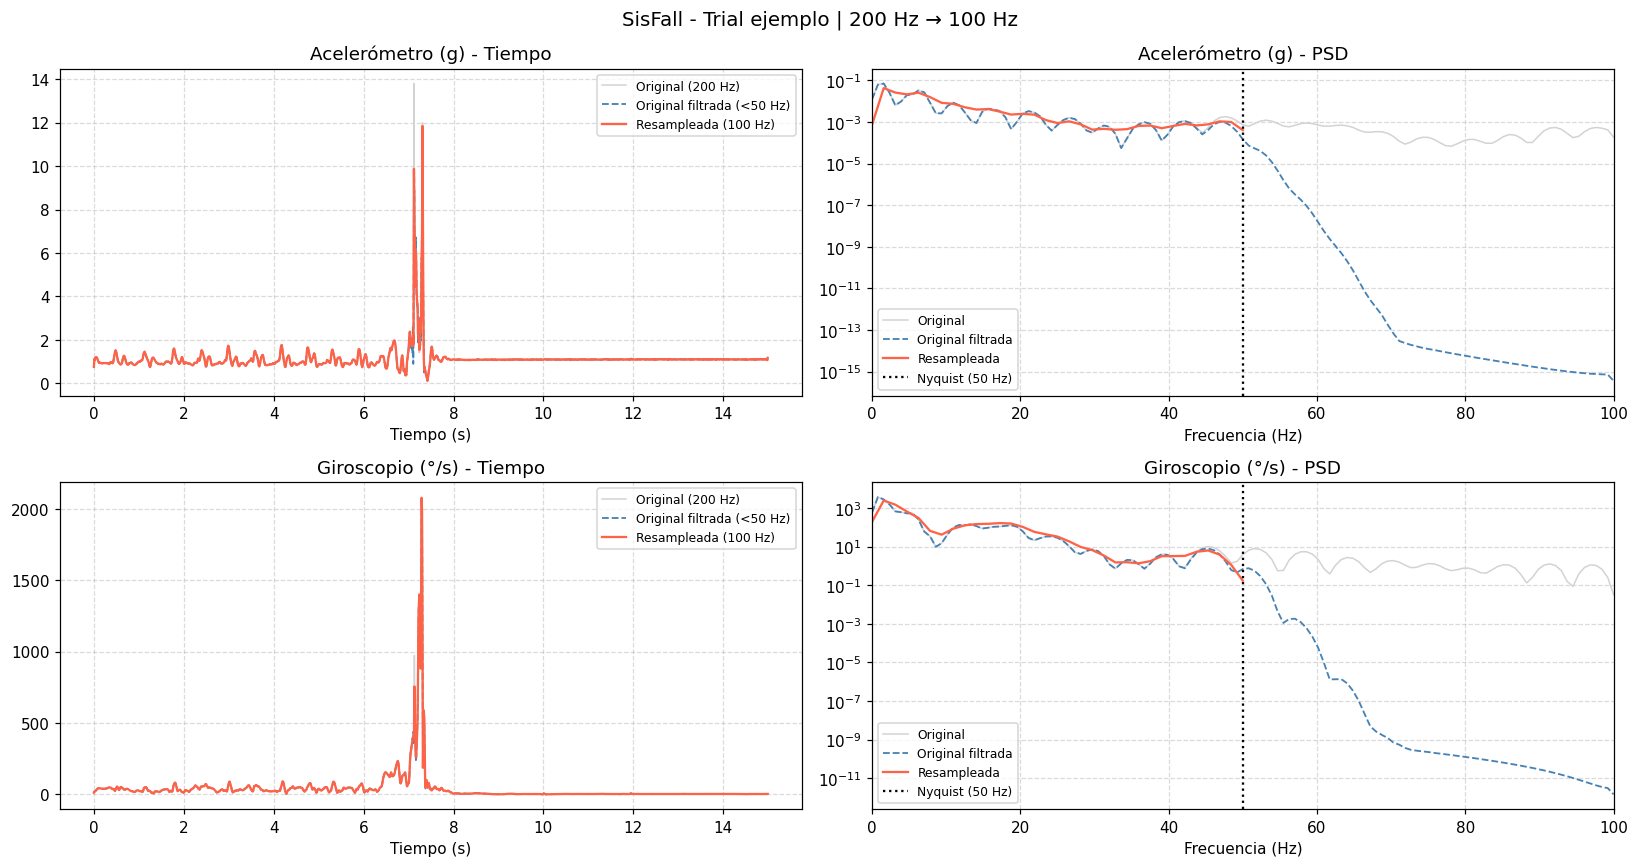

In [33]:
# --- 3a. Visualización de un trial de ejemplo ---------------------------------
sf_falls  = df_sf[df_sf["Activity_Label"] == "Fall"]
sf_ej     = sf_falls[["Subject","Activity_Code","Trial"]].drop_duplicates().iloc[0]
sf_trial  = sf_falls[(sf_falls["Subject"]       == sf_ej["Subject"]) &
                      (sf_falls["Activity_Code"] == sf_ej["Activity_Code"]) &
                      (sf_falls["Trial"]         == sf_ej["Trial"])]

a_orig = np.sqrt(sf_trial["Ax"]**2 + sf_trial["Ay"]**2 + sf_trial["Az"]**2).values
g_orig = np.sqrt(sf_trial["Gx"]**2 + sf_trial["Gy"]**2 + sf_trial["Gz"]**2).values

# Resamplear el trial
a_res = resample_trial(a_orig, FS_SF, FS_TARGET)
g_res = resample_trial(g_orig, FS_SF, FS_TARGET)

# Ejes temporales
t_orig = np.arange(len(a_orig)) / FS_SF
t_res  = np.arange(len(a_res))  / FS_TARGET

# Señal original filtrada a la misma banda (referencia justa)
a_filt = lowpass(a_orig, FS_SF)
g_filt = lowpass(g_orig, FS_SF)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f"{DS_NAME} - Trial ejemplo | {FS_SF} Hz → {FS_TARGET} Hz", fontsize=13)

for row, (name, orig, filt, resampled) in enumerate([
        ("Acelerómetro (g)",    a_orig, a_filt, a_res),
        ("Giroscopio (°/s)",    g_orig, g_filt, g_res)]):

    # Dominio del tiempo
    ax = axes[row, 0]
    ax.plot(t_orig, orig,      color="lightgray", lw=1,   label=f"Original ({FS_SF} Hz)")
    ax.plot(t_orig, filt,      color="steelblue", lw=1.2, label=f"Original filtrada (<{FS_TARGET//2} Hz)", ls="--")
    ax.plot(t_res,  resampled, color="tomato",    lw=1.5, label=f"Resampleada ({FS_TARGET} Hz)")
    ax.set_title(f"{name} - Tiempo")
    ax.set_xlabel("Tiempo (s)")
    ax.legend(fontsize=8)

    # Dominio frecuencial (PSD)
    ax = axes[row, 1]
    nperseg_o = min(256, len(orig)//2)
    nperseg_r = min(64,  len(resampled)//2)
    fo, Po = welch(orig,      fs=FS_SF,     nperseg=nperseg_o)
    ff, Pf = welch(filt,      fs=FS_SF,     nperseg=nperseg_o)
    fr, Pr = welch(resampled, fs=FS_TARGET, nperseg=nperseg_r)
    ax.semilogy(fo, Po, color="lightgray", lw=1,   label="Original")
    ax.semilogy(ff, Pf, color="steelblue", lw=1.2, ls="--", label="Original filtrada")
    ax.semilogy(fr, Pr, color="tomato",    lw=1.5, label="Resampleada")
    ax.axvline(FS_TARGET/2, color="black", ls=":", label=f"Nyquist ({FS_TARGET//2} Hz)")
    ax.set_xlim(0, FS_SF//2)
    ax.set_title(f"{name} - PSD")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

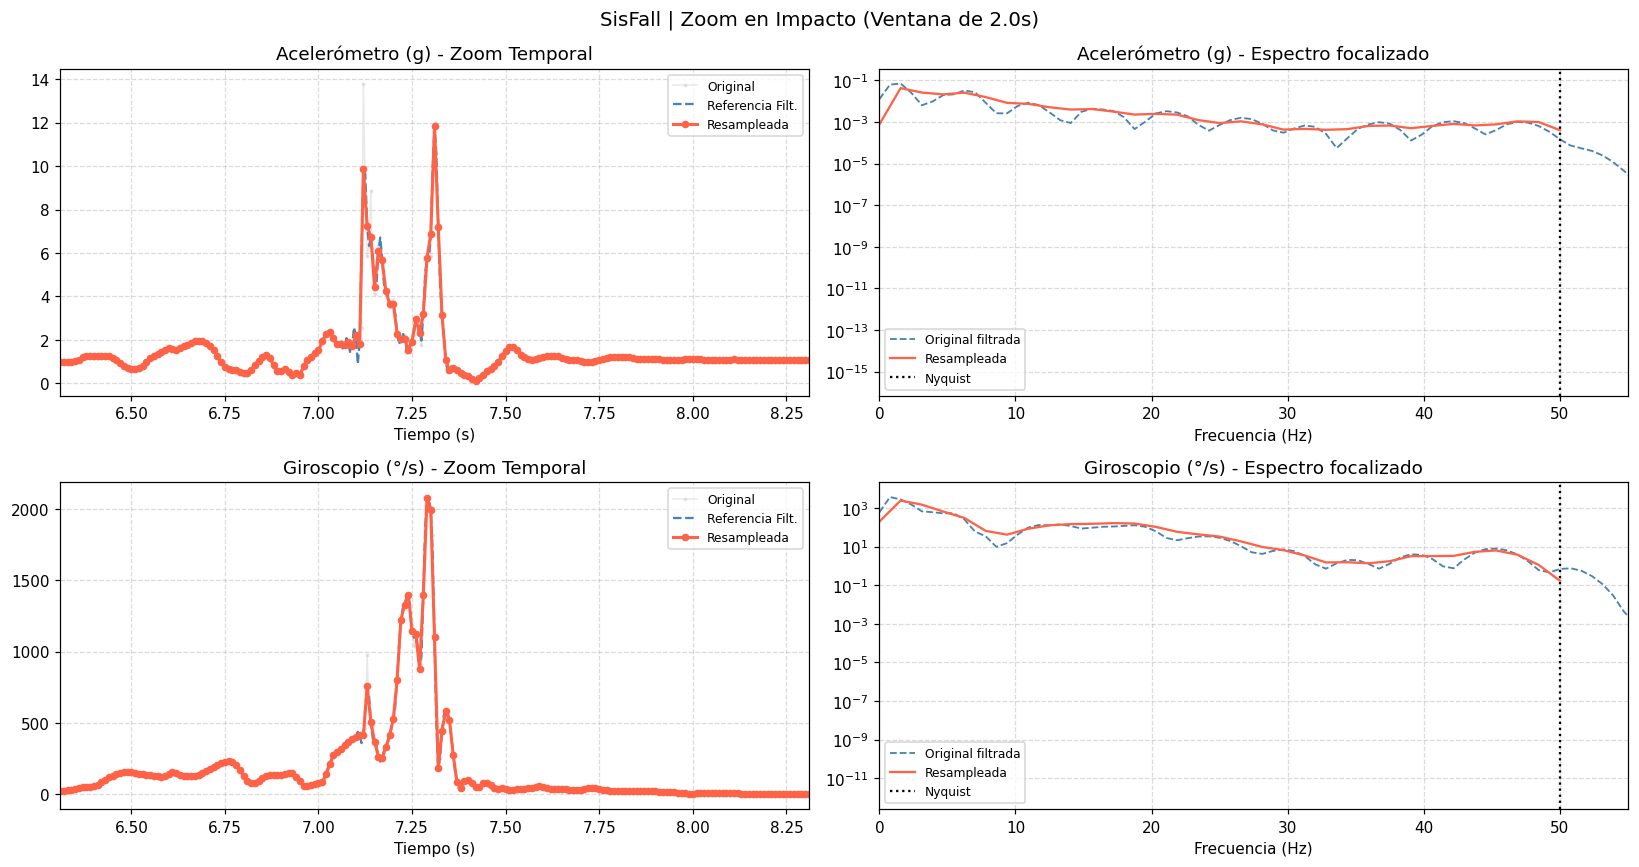

In [34]:
# --- Zoom en Ventana de Impacto (±1s) -----------------------------------------
# Localizamos el pico en la aceleración resampleada para centrar el zoom
peak_idx_res = a_res.argmax()
t_peak = t_res[peak_idx_res]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f"{DS_NAME} | Zoom en Impacto (Ventana de {EVAL_WINDOW_SEC}s)", fontsize=13)

for row, (name, orig, filt, resampled) in enumerate([
        ("Acelerómetro (g)",    a_orig, a_filt, a_res),
        ("Giroscopio (°/s)",    g_orig, g_filt, g_res)]):

    # Dominio del tiempo CON ZOOM
    ax = axes[row, 0]
    ax.plot(t_orig, orig,      color="lightgray", lw=1,   label="Original", marker='.', ms=3, alpha=0.5)
    ax.plot(t_orig, filt,      color="steelblue", lw=1.5, label="Referencia Filt.", ls="--")
    ax.plot(t_res,  resampled, color="tomato",    lw=2,   label="Resampleada", marker='o', ms=4)

    ax.set_xlim(t_peak - EVAL_WINDOW_SEC/2, t_peak + EVAL_WINDOW_SEC/2)
    ax.set_title(f"{name} - Zoom Temporal")
    ax.set_xlabel("Tiempo (s)")
    ax.legend(fontsize=8)

    # Dominio frecuencial (PSD) - Se mantiene igual para contexto
    ax = axes[row, 1]
    nperseg_r = min(64,  len(resampled)//2)
    ff, Pf = welch(filt,      fs=FS_SF,     nperseg=min(256, len(filt)//2))
    fr, Pr = welch(resampled, fs=FS_TARGET, nperseg=nperseg_r)
    ax.semilogy(ff, Pf, color="steelblue", lw=1.2, ls="--", label="Original filtrada")
    ax.semilogy(fr, Pr, color="tomato",    lw=1.5, label="Resampleada")
    ax.axvline(FS_TARGET/2, color="black", ls=":", label="Nyquist")
    ax.set_xlim(0, FS_TARGET/2 + 5)
    ax.set_title(f"{name} - Espectro focalizado")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [35]:
# --- 3b. Validación global ----------------------------------------------------
sf_metrics = run_global_validation(df_sf, FS_SF)
print_summary(sf_metrics, DS_NAME, FS_SF)
RESULTS[DS_NAME] = {"metrics": sf_metrics, "fs_orig": FS_SF}

  Procesando 1798 trials (Fall)…

  SisFall  |  200 Hz  →  100 Hz

  Sensor: ACC
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       20.952   21.603   30.504   38.584
  Pearson r               0.955    0.990    0.997    0.999
  DTW normalizado         0.010    0.010    0.023    0.060
  Phase shift (ms)        0.150    0.000    0.000  270.000
  Aten. pico filtrado (%)    4.914    3.724   13.252   25.882

  Sensor: GYRO
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       24.379   25.184   33.653   39.212
  Pearson r               0.975    0.997    1.000    1.000
  DTW normalizado         0.005    0.004    0.016    0.083
  Phase shift (ms)       12.353    5.000   35.000  805.000
  Aten. pico filtrado (%)    3.462    1.887   11.147  367.691



---
## 4 · FallAllD — 238 Hz → 100 Hz

Caso polifásico: razón 50/238 = 25/119, no entera. `resample_poly` maneja esto correctamente con un filtro FIR polifásico.

In [36]:
DS_NAME = "FallAllD"
info = datasets[DS_NAME]
assert info["df"] is not None, f"Dataset {DS_NAME} no disponible"

df_fa = info["df"]
FS_FA = info["fs"]    # 238 Hz
print(f"{DS_NAME}: {len(df_fa):,} filas | fs_orig={FS_FA} Hz | caídas: {(df_fa['Activity_Label']=='Fall').sum():,}")
up_f, down_f = get_poly_factors(FS_FA, FS_TARGET)
print(f"Factores polifásicos: up={up_f}, down={down_f}  →  {FS_FA} × {up_f}/{down_f} = {FS_FA*up_f/down_f:.4f} Hz")

FallAllD: 8,558,480 filas | fs_orig=238 Hz | caídas: 2,218,160
Factores polifásicos: up=50, down=119  →  238 × 50/119 = 100.0000 Hz


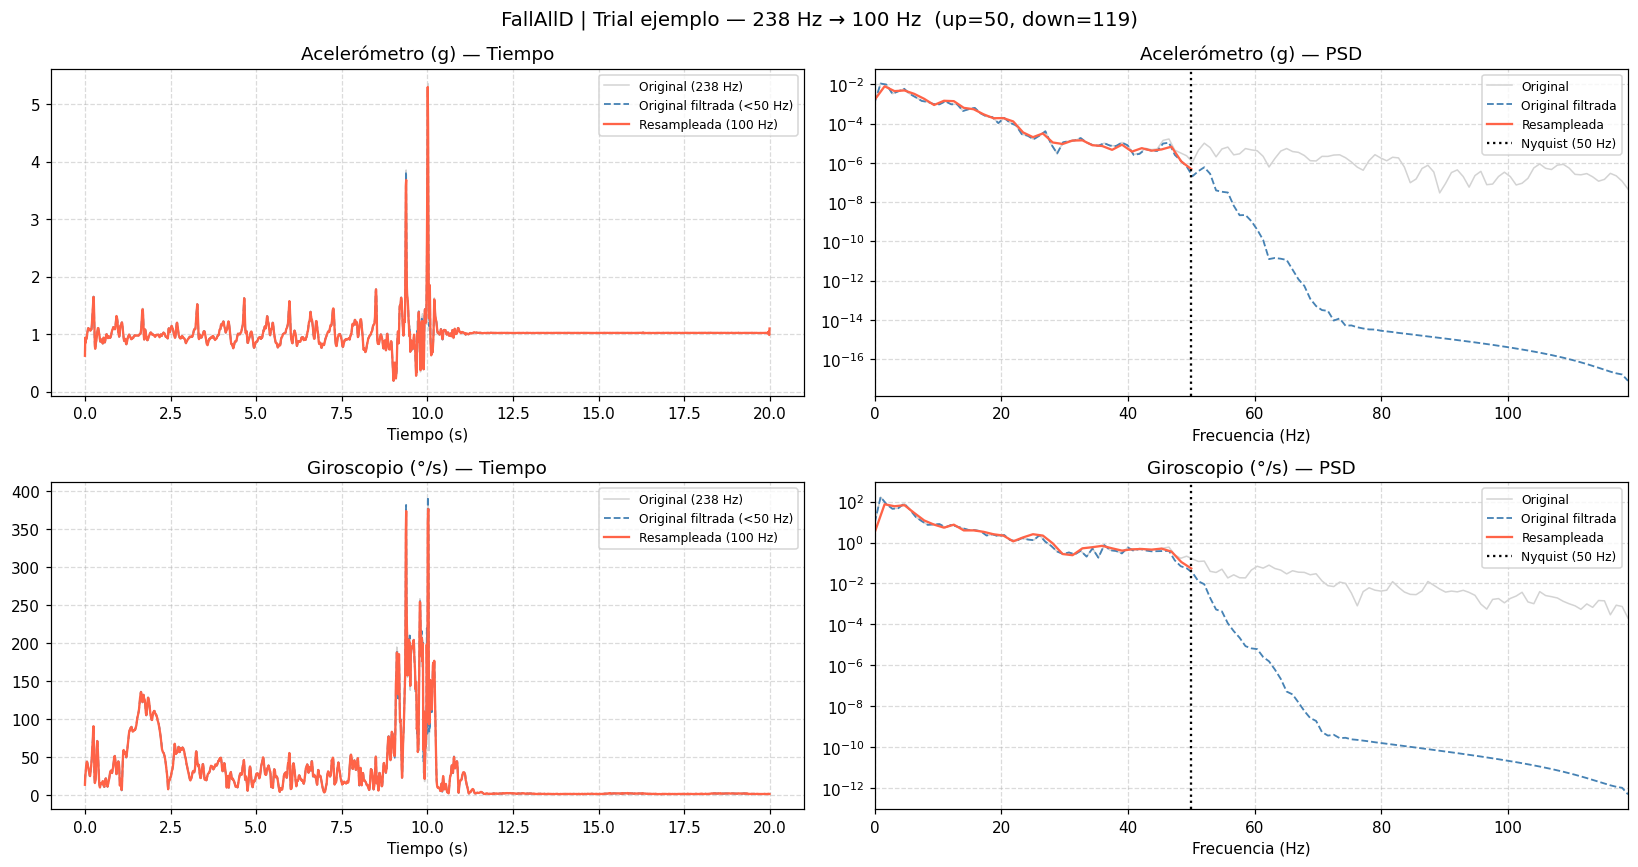

In [37]:
# --- 6a. Visualización de un trial de ejemplo ---------------------------------
fa_falls  = df_fa[df_fa["Activity_Label"] == "Fall"]
fa_ej     = fa_falls[["Subject","Activity_Code","Trial"]].drop_duplicates().iloc[0]
fa_trial  = fa_falls[(fa_falls["Subject"]       == fa_ej["Subject"]) &
                      (fa_falls["Activity_Code"] == fa_ej["Activity_Code"]) &
                      (fa_falls["Trial"]         == fa_ej["Trial"])]

a_orig = np.sqrt(fa_trial["Ax"]**2 + fa_trial["Ay"]**2 + fa_trial["Az"]**2).values
g_orig = np.sqrt(fa_trial["Gx"]**2 + fa_trial["Gy"]**2 + fa_trial["Gz"]**2).values

a_res = resample_trial(a_orig, FS_FA, FS_TARGET)
g_res = resample_trial(g_orig, FS_FA, FS_TARGET)

t_orig = np.arange(len(a_orig)) / FS_FA
t_res  = np.arange(len(a_res))  / FS_TARGET
a_filt = lowpass(a_orig, FS_FA)
g_filt = lowpass(g_orig, FS_FA)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f"{DS_NAME} | Trial ejemplo — {FS_FA} Hz → {FS_TARGET} Hz  (up={up_f}, down={down_f})", fontsize=13)

for row, (name, orig, filt, resampled) in enumerate([
        ("Acelerómetro (g)",  a_orig, a_filt, a_res),
        ("Giroscopio (°/s)", g_orig, g_filt, g_res)]):

    ax = axes[row, 0]
    ax.plot(t_orig, orig,      color="lightgray", lw=1,   label=f"Original ({FS_FA} Hz)")
    ax.plot(t_orig, filt,      color="steelblue", lw=1.2, ls="--", label=f"Original filtrada (<{FS_TARGET//2} Hz)")
    ax.plot(t_res,  resampled, color="tomato",    lw=1.5, label=f"Resampleada ({FS_TARGET} Hz)")
    ax.set_title(f"{name} — Tiempo")
    ax.set_xlabel("Tiempo (s)")
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    nperseg_o = min(256, len(orig)//2)
    nperseg_r = min(64,  len(resampled)//2)
    fo, Po = welch(orig,      fs=FS_FA,     nperseg=nperseg_o)
    ff, Pf = welch(filt,      fs=FS_FA,     nperseg=nperseg_o)
    fr, Pr = welch(resampled, fs=FS_TARGET, nperseg=nperseg_r)
    ax.semilogy(fo, Po, color="lightgray", lw=1,   label="Original")
    ax.semilogy(ff, Pf, color="steelblue", lw=1.2, ls="--", label="Original filtrada")
    ax.semilogy(fr, Pr, color="tomato",    lw=1.5, label="Resampleada")
    ax.axvline(FS_TARGET/2, color="black", ls=":", label=f"Nyquist ({FS_TARGET//2} Hz)")
    ax.set_xlim(0, FS_FA//2)
    ax.set_title(f"{name} — PSD")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

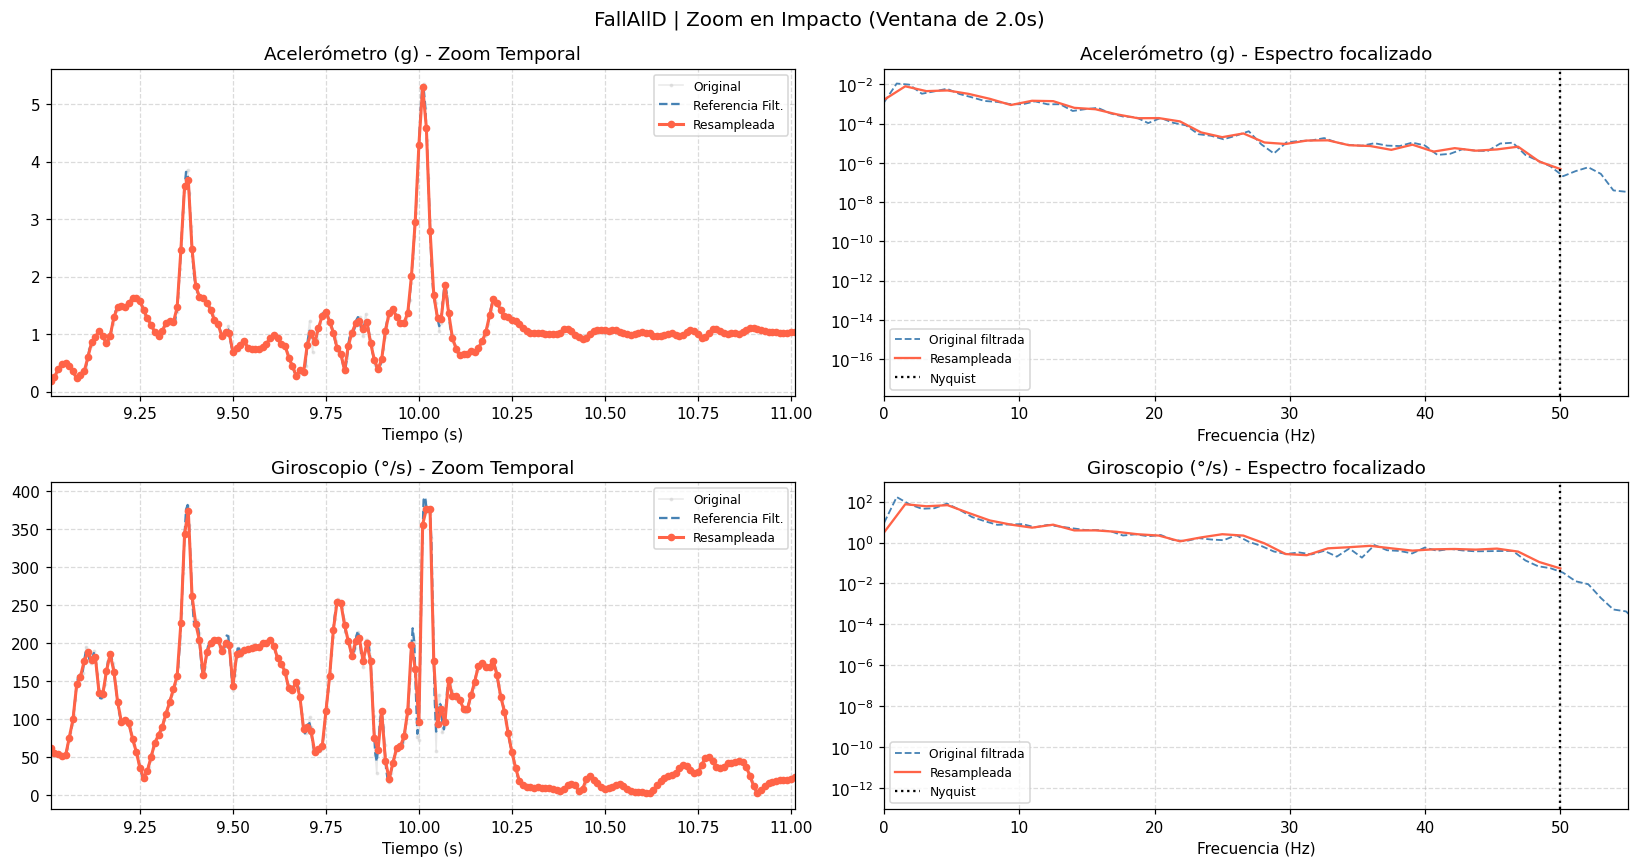

In [38]:
# --- Zoom en Ventana de Impacto (±1s) -----------------------------------------
# Localizamos el pico en la aceleración resampleada para centrar el zoom
peak_idx_res = a_res.argmax()
t_peak = t_res[peak_idx_res]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f"{DS_NAME} | Zoom en Impacto (Ventana de {EVAL_WINDOW_SEC}s)", fontsize=13)

for row, (name, orig, filt, resampled) in enumerate([
        ("Acelerómetro (g)",    a_orig, a_filt, a_res),
        ("Giroscopio (°/s)",    g_orig, g_filt, g_res)]):

    # Dominio del tiempo CON ZOOM
    ax = axes[row, 0]
    ax.plot(t_orig, orig,      color="lightgray", lw=1,   label="Original", marker='.', ms=3, alpha=0.5)
    ax.plot(t_orig, filt,      color="steelblue", lw=1.5, label="Referencia Filt.", ls="--")
    ax.plot(t_res,  resampled, color="tomato",    lw=2,   label="Resampleada", marker='o', ms=4)

    ax.set_xlim(t_peak - EVAL_WINDOW_SEC/2, t_peak + EVAL_WINDOW_SEC/2)
    ax.set_title(f"{name} - Zoom Temporal")
    ax.set_xlabel("Tiempo (s)")
    ax.legend(fontsize=8)

    # Dominio frecuencial (PSD) - Se mantiene igual para contexto
    ax = axes[row, 1]
    nperseg_r = min(64,  len(resampled)//2)
    ff, Pf = welch(filt,      fs=FS_FA,     nperseg=min(256, len(filt)//2))
    fr, Pr = welch(resampled, fs=FS_TARGET, nperseg=nperseg_r)
    ax.semilogy(ff, Pf, color="steelblue", lw=1.2, ls="--", label="Original filtrada")
    ax.semilogy(fr, Pr, color="tomato",    lw=1.5, label="Resampleada")
    ax.axvline(FS_TARGET/2, color="black", ls=":", label="Nyquist")
    ax.set_xlim(0, FS_TARGET/2 + 5)
    ax.set_title(f"{name} - Espectro focalizado")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [39]:
# --- 5b. Validación global ----------------------------------------------------
fa_metrics = run_global_validation(df_fa, FS_FA)
print_summary(fa_metrics, DS_NAME, FS_FA)
RESULTS[DS_NAME] = {"metrics": fa_metrics, "fs_orig": FS_FA}

  Procesando 466 trials (Fall)…

  FallAllD  |  238 Hz  →  100 Hz

  Sensor: ACC
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       19.520   19.002   30.963   38.587
  Pearson r               0.918    0.973    0.997    0.999
  DTW normalizado         0.013    0.012    0.026    0.060
  Phase shift (ms)        0.457    0.000    0.000  140.000
  Aten. pico filtrado (%)    5.635    4.674   13.667   34.257

  Sensor: GYRO
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       19.888   20.192   30.802   35.659
  Pearson r               0.939    0.988    0.999    1.000
  DTW normalizado         0.009    0.008    0.019    0.057
  Phase shift (ms)       37.784    4.202  219.601  998.403
  Aten. pico filtrado (%)    4.381    2.912   12.686   66.729



---
## 5 · Resumen comparativo cross-dataset

Ejecutar esta sección **después** de haber corrido todas las secciones de dataset que se quieran incluir.  
Compara visualmente los cinco indicadores para entender qué dataset sale mejor o peor parado al resamplear a 100 Hz.

In [40]:
assert RESULTS, "No hay resultados. Ejecutá al menos una sección de dataset primero."

# --- 8a. Tabla resumen --------------------------------------------------------
metrics_order = ["snr_db", "pearson_r", "dtw_norm", "phase_shift_ms", "peak_atten_pct"]
metric_labels = {
    "snr_db":          "SNR in-band (dB)  ↑ mejor",
    "pearson_r":       "Pearson r          ↑ mejor",
    "dtw_norm":        "DTW norm.          ↓ mejor",
    "phase_shift_ms":  "Phase shift (ms)   ↓ mejor",
    "peak_atten_pct":  "Aten. pico filt. % ↓ mejor",
}

summary_rows = []
for ds_name, res in RESULTS.items():
    fs_o = res["fs_orig"]
    df_m = res["metrics"]
    for sensor in ("acc", "gyro"):
        sub = df_m[df_m["sensor"] == sensor]
        row = {"Dataset": ds_name, "fs_orig": fs_o, "Sensor": sensor.upper()}
        for m in metrics_order:
            row[m + "_mean"] = sub[m].mean()
            row[m + "_p95"]  = sub[m].quantile(0.95)
        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

print("\n  RESUMEN GLOBAL — Media de cada métrica por dataset y sensor")
print("  " + "-"*80)
for _, r in df_summary.iterrows():
    print(f"  {r['Dataset']:10s} {r['Sensor']:5s} ({r['fs_orig']:3.0f}→{FS_TARGET}Hz) | "
          f"SNR {r['snr_db_mean']:6.1f} dB | "
          f"r {r['pearson_r_mean']:.4f} | "
          f"DTW {r['dtw_norm_mean']:.4f} | "
          f"Δt {r['phase_shift_ms_mean']:.1f} ms | "
          f"Aten {r['peak_atten_pct_mean']:.1f}%")


  RESUMEN GLOBAL — Media de cada métrica por dataset y sensor
  --------------------------------------------------------------------------------
  SisFall    ACC   (200→100Hz) | SNR   21.0 dB | r 0.9546 | DTW 0.0096 | Δt 0.2 ms | Aten 4.9%
  SisFall    GYRO  (200→100Hz) | SNR   24.4 dB | r 0.9751 | DTW 0.0052 | Δt 12.4 ms | Aten 3.5%
  FallAllD   ACC   (238→100Hz) | SNR   19.5 dB | r 0.9177 | DTW 0.0131 | Δt 0.5 ms | Aten 5.6%
  FallAllD   GYRO  (238→100Hz) | SNR   19.9 dB | r 0.9394 | DTW 0.0090 | Δt 37.8 ms | Aten 4.4%


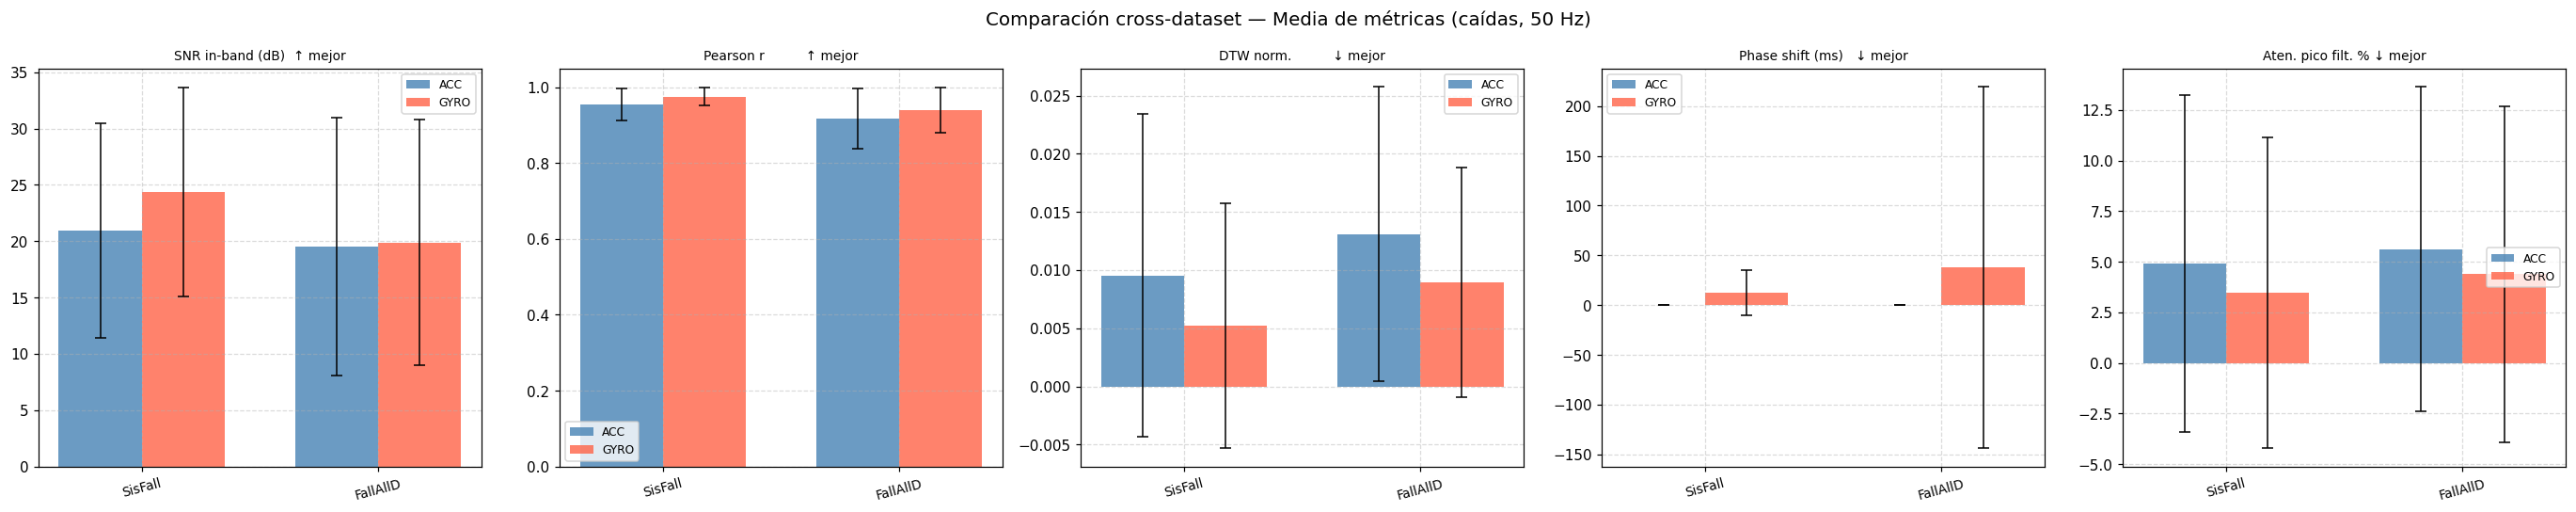

In [41]:
# --- 8b. Gráficos comparativos ------------------------------------------------
ds_names  = list(RESULTS.keys())
n_ds      = len(ds_names)
colors    = {"ACC": "steelblue", "GYRO": "tomato"}

fig, axes = plt.subplots(1, len(metrics_order), figsize=(5 * len(metrics_order), 5))
fig.suptitle("Comparación cross-dataset — Media de métricas (caídas, 50 Hz)", fontsize=13)

for ax, metric in zip(axes, metrics_order):
    x     = np.arange(n_ds)
    width = 0.35
    for i, sensor in enumerate(("ACC", "GYRO")):
        sub = df_summary[df_summary["Sensor"] == sensor]
        vals = [sub[sub["Dataset"] == ds][metric + "_mean"].values[0]
                if ds in sub["Dataset"].values else np.nan
                for ds in ds_names]
        p95  = [sub[sub["Dataset"] == ds][metric + "_p95"].values[0]
                if ds in sub["Dataset"].values else np.nan
                for ds in ds_names]
        err  = [max(0.0, p - v) if (p == p and v == v) else 0.0
                for p, v in zip(p95, vals)]
        bars = ax.bar(x + i * width, vals, width, label=sensor,
                      color=colors[sensor], alpha=0.8,
                      yerr=err, capsize=4, error_kw={"elinewidth": 1})

    ax.set_title(metric_labels[metric], fontsize=9)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(ds_names, rotation=15, fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

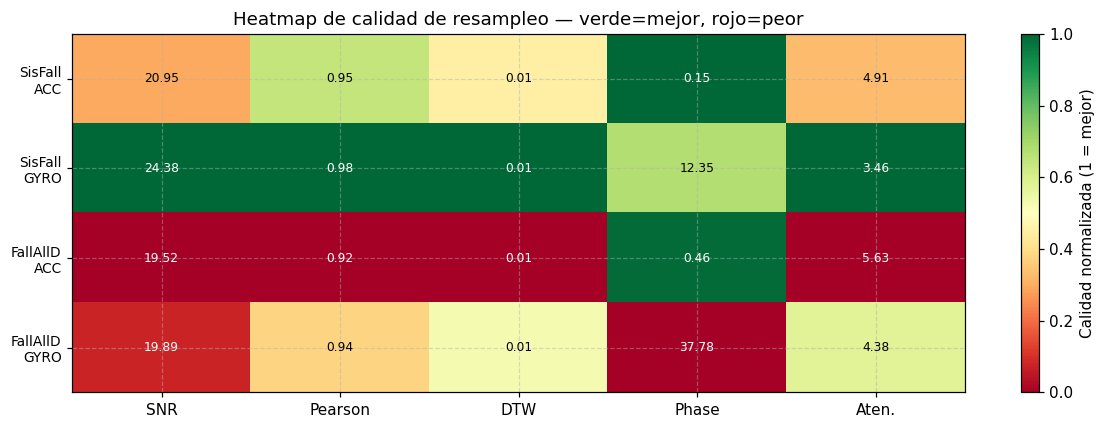


Nota: Los valores crudos están impresos dentro de cada celda.
La escala de color es relativa entre los datasets disponibles en RESULTS.


In [42]:
# ── 8c. Heatmap de calidad normalizada ───────────────────────────────────
# Convierte todas las métricas a una escala 0-1 donde 1 = mejor resultado.
# Permite ver de un vistazo qué dataset-sensor tiene el peor compromiso global.

from matplotlib.colors import Normalize
from matplotlib.cm import RdYlGn

# Métricas donde mayor = mejor
higher_is_better = {"snr_db", "pearson_r"}

heatmap_data = []
row_labels   = []

for _, r in df_summary.iterrows():
    row_labels.append(f"{r['Dataset']}\n{r['Sensor']}")
    heatmap_data.append([r[m + "_mean"] for m in metrics_order])

heatmap_arr = np.array(heatmap_data, dtype=float)

# Normalizar columna a columna
heatmap_norm = np.zeros_like(heatmap_arr)
for j, m in enumerate(metrics_order):
    col = heatmap_arr[:, j]
    mn, mx = np.nanmin(col), np.nanmax(col)
    if mx == mn:
        heatmap_norm[:, j] = 1.0
    elif m in higher_is_better:
        heatmap_norm[:, j] = (col - mn) / (mx - mn)
    else:
        heatmap_norm[:, j] = 1 - (col - mn) / (mx - mn)

col_labels = [metric_labels[m].split(" ")[0] for m in metrics_order]

fig, ax = plt.subplots(figsize=(len(metrics_order) * 2.2, max(4, len(row_labels) * 0.7)))
im = ax.imshow(heatmap_norm, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

for i in range(len(row_labels)):
    for j in range(len(metrics_order)):
        raw_val = heatmap_arr[i, j]
        txt = f"{raw_val:.2f}" if abs(raw_val) < 100 else f"{raw_val:.0f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                color="black" if 0.25 < heatmap_norm[i, j] < 0.75 else "white")

plt.colorbar(im, ax=ax, label="Calidad normalizada (1 = mejor)")
ax.set_title("Heatmap de calidad de resampleo — verde=mejor, rojo=peor", fontsize=12)
plt.tight_layout()
plt.show()

print("\nNota: Los valores crudos están impresos dentro de cada celda.")
print("La escala de color es relativa entre los datasets disponibles en RESULTS.")

## 6 · Exportación de resultados a Azure Data Lake

Guardamos el resumen consolidado de métricas en la zona 'plata' para su posterior análisis o reporte.

In [43]:
try:
    # 1. Preparar el DataFrame
    # Usamos el df_summary generado en la sección 5
    output_filename = f"resampling_validation_results_{FS_TARGET}hz.csv"
    csv_buffer = io.StringIO()
    df_summary.to_csv(csv_buffer, index=False)

    # 2. Conectar al contenedor 'plata'
    fs_plata = service_client.get_file_system_client("plata")
    dir_plata_falls = fs_plata.get_directory_client("falls")

    # Asegurar que el directorio existe
    file_client = dir_plata_falls.get_file_client(output_filename)

    # 3. Subir el archivo
    file_client.upload_data(csv_buffer.getvalue(), overwrite=True)

    print(f"✓ Resultados exportados exitosamente a: plata/falls/{output_filename}")
    print(f"  Total de combinaciones Dataset/Sensor: {len(df_summary)}")

except Exception as e:
    print(f"✗ Error al exportar a Azure: {e}")

✓ Resultados exportados exitosamente a: plata/falls/resampling_validation_results_100hz.csv
  Total de combinaciones Dataset/Sensor: 4
